# CFG sweep on a single CV simulation

Goal: test whether increasing the **classifier-free guidance** scale at inference reduces the parameter-dependent stellar-mass bias seen in CV/1P (paper_figures.ipynb).

Hypothesis: the bias is conditional regression-toward-the-training-marginal (training set is SB35, CV is OOD-narrow). Pushing `cfg_scale > 1` should pull samples toward the conditional mode and reduce the bias for stars without breaking DM/Gas.

Pipeline mirrors `run_test_suite_parallel.sh` / `dmo_to_hydro_CV.ipynb` but for one sim, sweeping `cfg_scale`.

In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

from contextlib import nullcontext
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import torch
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from data import NormStats, log_transform
from train import FlowMatchingLit
from test_suite.pipeline import (
    pixelize_z_projection,
    extract_multiscale,
    normalize_cutout,
    _denormalize_to_physical,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda


## Configuration

In [2]:
# ── Sim selection ────────────────────────────────────────────────────────────
SIM_ID = 12                               # CV_<SIM_ID>
NBODY_PATH    = f'/mnt/ceph/users/camels/Sims/IllustrisTNG_DM/L50n512/CV/CV_{SIM_ID}'
HYDRO_SNAPDIR = f'/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/CV/CV_{SIM_ID}/snapdir_090'
GROUP_CATALOG = f'/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/CV/CV_{SIM_ID}/groups_090'
PARAM_FILE    = '/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/CV/CosmoAstroSeed_IllustrisTNG_L50n512_CV.txt'

# ── Model ────────────────────────────────────────────────────────────────────
RUN_DIR   = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
CKPT_PATH = RUN_DIR / 'checkpoints' / 'last.ckpt'

# ── Box / grid ───────────────────────────────────────────────────────────────
BOX            = 50.0
NPIX           = 1024
PATCH_PIX      = 128
SNAPSHOT       = 90
PROJ_FRAC      = 1.0
HALO_MASS_MIN  = 1e13

# ── Generation ───────────────────────────────────────────────────────────────
N_STEPS    = 50
BATCH_SIZE = 16
USE_AMP    = True

# ── CFG sweep ────────────────────────────────────────────────────────────────
CFG_SCALES = [1.0, 1.5, 2.0, 3.0, 5.0, 7.0]
SEED       = 0  # fix the noise schedule across CFG scales for a fair comparison

MPC_PER_PIX = BOX / NPIX                 # ≈ 0.0488 Mpc/h
PATCH_MPC   = PATCH_PIX * MPC_PER_PIX    # ≈ 6.25 Mpc/h

## Load model and norm stats

In [3]:
norm_stats = NormStats.load(RUN_DIR / 'norm_stats.npz')
print(f'two-head:    {norm_stats.stars_two_head}')
print(f'target_mean: {norm_stats.target_mean}')
print(f'target_std:  {norm_stats.target_std}')

lit = FlowMatchingLit.load_from_checkpoint(CKPT_PATH, map_location=device)
lit.eval().to(device)
fm = lit.fm
ckpt = torch.load(CKPT_PATH, map_location='cpu')
print(f'epoch={ckpt["epoch"]}, out_channels={getattr(fm, "out_channels", 3)}')

two-head:    True
target_mean: [9.911639  9.17901   1.5460707]
target_std:  [0.46349886 0.40898287 2.950175  ]


/tmp/ipykernel_1319089/2815323885.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location='cpu')


epoch=80, out_channels=4


## Project DMO particles → 2D full-box map

In [4]:
def _dmo_files(root, snap):
    single = Path(root) / f'snap_{snap:03d}.hdf5'
    if single.exists():
        return [str(single)]
    return sorted(glob.glob(str(Path(root) / f'snapdir_{snap:03d}' / f'snap_{snap:03d}.*.hdf5')))

snap_files = _dmo_files(NBODY_PATH, SNAPSHOT)
pos_chunks, mp = [], None
for f in snap_files:
    with h5py.File(f, 'r') as h:
        pos_chunks.append(h['PartType1/Coordinates'][:])
        if mp is None:
            mp = float(h['Header'].attrs['MassTable'][1]) * 1e10
dmo_pos  = np.concatenate(pos_chunks) / 1000.0     # Mpc/h
dmo_mass = np.full(len(dmo_pos), mp, dtype=np.float32)
if PROJ_FRAC < 1.0:
    sel = dmo_pos[:, 2] < BOX * PROJ_FRAC
    dmo_pos, dmo_mass = dmo_pos[sel], dmo_mass[sel]

dmo_fullbox = pixelize_z_projection(dmo_pos, dmo_mass, BOX, NPIX)
print(f'DMO full-box shape={dmo_fullbox.shape}, total mass={dmo_fullbox.sum():.3e}')

DMO full-box shape=(1024, 1024), total mass=1.041e+16


## Load halo catalog and sim params

In [5]:
df = pd.read_csv(PARAM_FILE, sep=r'\s+', comment='#', header=None, skiprows=1)
row = df[df[0] == f'CV_{SIM_ID}']
sim_params = row.iloc[0, 1:36].values.astype(np.float32)
print(f'CV_{SIM_ID}: Omega_m={sim_params[0]:.4f}, sigma_8={sim_params[1]:.4f}')

# FoF group catalog (multi-chunk)
files = sorted(glob.glob(f'{GROUP_CATALOG}/fof_subhalo_tab_{SNAPSHOT:03d}.*.hdf5'))
ms, ps_3d = [], []
for f in files:
    with h5py.File(f, 'r') as h:
        if 'Group/GroupMass' in h:
            ms.append(h['Group/GroupMass'][:])
            ps_3d.append(h['Group/GroupPos'][:])
halo_mass = np.concatenate(ms) * 1e10
halo_pos  = np.concatenate(ps_3d) / 1e3
sel = halo_mass > HALO_MASS_MIN
halo_mass, halo_pos = halo_mass[sel], halo_pos[sel]

halos = [
    {'halo_center': p[:2], 'halo_mass': float(m), 'params': sim_params}
    for p, m in zip(halo_pos, halo_mass)
]
print(f'Found {len(halos)} halos with M > {HALO_MASS_MIN:.0e}')

CV_12: Omega_m=0.3000, sigma_8=0.8000
Found 46 halos with M > 1e+13


## Extract DMO multiscale cutouts

In [6]:
px_per_mpc = NPIX / BOX
halo_cutouts = []
for h in tqdm(halos, desc='cutouts'):
    cx = int(h['halo_center'][0] * px_per_mpc) % NPIX
    cy = int(h['halo_center'][1] * px_per_mpc) % NPIX
    c, ls = extract_multiscale(dmo_fullbox, cx, cy, target_res=PATCH_PIX)
    halo_cutouts.append({'condition': c, 'large_scale': ls})
print(f'{len(halo_cutouts)} cutouts')

cutouts:   0%|          | 0/46 [00:00<?, ?it/s]

46 cutouts


## Generate at each CFG scale

Same noise schedule (deterministic Euler with `x0 = condition` for the StochasticInterpolant path; pure noise + fixed seed for FlowMatching). Only `cfg_scale` changes.

In [7]:
def generate_at_cfg(cutouts, fm, ns, sim_params, device, cfg_scale,
                    n_steps=50, batch_size=16, use_amp=True, seed=0):
    """Run inference at a fixed CFG scale, denormalize to physical units."""
    out = []
    with torch.no_grad():
        for s in tqdm(range(0, len(cutouts), batch_size),
                      desc=f'cfg={cfg_scale}', leave=False):
            batch = cutouts[s:s + batch_size]
            cs, ls, ps = zip(*[normalize_cutout(hc, ns, sim_params) for hc in batch])
            cond_t = torch.from_numpy(np.stack(cs).astype(np.float32)).to(device)
            ls_t   = torch.from_numpy(np.stack(ls).astype(np.float32)).to(device)
            par_t  = torch.from_numpy(np.stack(ps).astype(np.float32)).to(device)

            # Fix the per-batch RNG so noise is identical across CFG scales
            if device.type == 'cuda':
                torch.cuda.manual_seed_all(seed + s)
            torch.manual_seed(seed + s)

            ctx = (torch.amp.autocast('cuda', dtype=torch.bfloat16)
                   if use_amp and device.type == 'cuda' else nullcontext())
            with ctx:
                gen = fm.sample(cond_t, ls_t, par_t,
                                n_steps=n_steps, cfg_scale=cfg_scale)

            gen_np = gen.float().cpu().numpy().astype(np.float32)
            out.append(_denormalize_to_physical(gen_np, ns))
    return np.concatenate(out, axis=0) if out else np.zeros((0, 3, PATCH_PIX, PATCH_PIX), np.float32)


gen_by_cfg = {}
for w in CFG_SCALES:
    print(f'\n=== cfg_scale = {w} ===')
    gen_by_cfg[w] = generate_at_cfg(
        halo_cutouts, fm, norm_stats, sim_params, device, cfg_scale=w,
        n_steps=N_STEPS, batch_size=BATCH_SIZE, use_amp=USE_AMP, seed=SEED,
    )
    print(f'  shape={gen_by_cfg[w].shape}')


=== cfg_scale = 1.0 ===


cfg=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== cfg_scale = 1.5 ===


cfg=1.5:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== cfg_scale = 2.0 ===


...

  shape=(46, 3, 128, 128)

=== cfg_scale = 5.0 ===


cfg=5.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== cfg_scale = 7.0 ===


cfg=7.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)


In [14]:
def generate_at_cfg_stars_only(cutouts, fm, ns, sim_params, device, cfg_scale,
                               n_steps=50, batch_size=16, use_amp=True, seed=0):
    """CFG applied only to the stars channels (ch 2 and 3).

    DM_hydro (ch0) and Gas (ch1) keep their standard cfg_scale=1 velocity so
    they are not perturbed by the guidance.  Stars occupancy (ch2) and Stars
    conditional-density (ch3) receive the full amplified guidance signal.
    """
    nc = fm.out_channels   # 4 for two-head
    out = []
    with torch.no_grad():
        for s in tqdm(range(0, len(cutouts), batch_size),
                      desc=f'cfg_stars={cfg_scale}', leave=False):
            batch = cutouts[s:s + batch_size]
            cs, ls, ps = zip(*[normalize_cutout(hc, ns, sim_params) for hc in batch])
            cond_t = torch.from_numpy(np.stack(cs).astype(np.float32)).to(device)
            ls_t   = torch.from_numpy(np.stack(ls).astype(np.float32)).to(device)
            par_t  = torch.from_numpy(np.stack(ps).astype(np.float32)).to(device)

            if device.type == 'cuda':
                torch.cuda.manual_seed_all(seed + s)
            torch.manual_seed(seed + s)

            B  = cond_t.shape[0]
            H  = cond_t.shape[2]
            W  = cond_t.shape[3]
            x  = torch.randn(B, nc, H, W, device=device)
            dt = 1.0 / n_steps

            ctx = (torch.amp.autocast('cuda', dtype=torch.bfloat16)
                   if use_amp and device.type == 'cuda' else nullcontext())
            with ctx:
                for i in range(n_steps):
                    t   = torch.full((B,), i * dt, device=device)
                    inp = torch.cat([x, cond_t, ls_t], dim=1)

                    if cfg_scale != 1.0:
                        v_cond   = fm.model(inp, t, par_t)
                        v_uncond = fm.model(inp, t, torch.zeros_like(par_t))
                        # DM + Gas: use standard conditional velocity (no amplification)
                        v = v_cond.clone()
                        # Stars occupancy + density: amplify the guidance
                        v[:, 2:] = (v_uncond[:, 2:]
                                    + cfg_scale * (v_cond[:, 2:] - v_uncond[:, 2:]))
                    else:
                        v = fm.model(inp, t, par_t)

                    x = x + v * dt

            gen_np = x.float().cpu().numpy().astype(np.float32)
            out.append(_denormalize_to_physical(gen_np, ns))

    return (np.concatenate(out, axis=0) if out
            else np.zeros((0, 3, PATCH_PIX, PATCH_PIX), np.float32))


gen_by_cfg_stars = {}
for w in CFG_SCALES:
    print(f'\n=== stars-only cfg_scale = {w} ===')
    gen_by_cfg_stars[w] = generate_at_cfg_stars_only(
        halo_cutouts, fm, norm_stats, sim_params, device, cfg_scale=w,
        n_steps=N_STEPS, batch_size=BATCH_SIZE, use_amp=USE_AMP, seed=SEED,
    )
    print(f'  shape={gen_by_cfg_stars[w].shape}')


=== stars-only cfg_scale = 1.0 ===


cfg_stars=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== stars-only cfg_scale = 1.5 ===


cfg_stars=1.5:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== stars-only cfg_scale = 2.0 ===


...

  shape=(46, 3, 128, 128)

=== stars-only cfg_scale = 5.0 ===


cfg_stars=5.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)

=== stars-only cfg_scale = 7.0 ===


cfg_stars=7.0:   0%|          | 0/3 [00:00<?, ?it/s]

  shape=(46, 3, 128, 128)


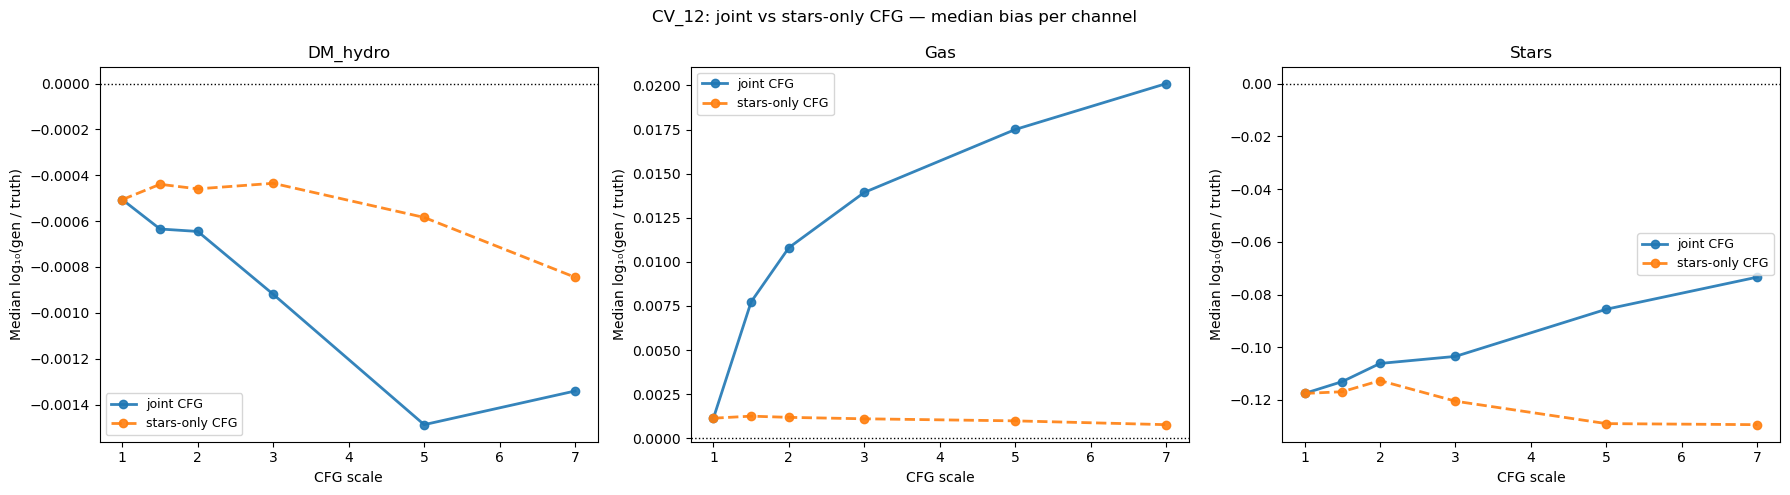

In [15]:
# ── Compare joint CFG vs stars-only CFG ──────────────────────────────────────
# Shows that stars-only CFG leaves Gas flat while still boosting Stars.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

CHANNEL_NAMES_ = ['DM_hydro', 'Gas', 'Stars']
for ax, ch, name in zip(axes, range(3), CHANNEL_NAMES_):
    for label, gen_dict, ls_, alpha in [
        ('joint CFG',      gen_by_cfg,       '-',  0.9),
        ('stars-only CFG', gen_by_cfg_stars, '--', 0.9),
    ]:
        meds = [np.median(per_halo_log_ratio(gen_dict[w], truth_patches, ch))
                for w in CFG_SCALES]
        ax.plot(CFG_SCALES, meds, marker='o', ls=ls_, lw=2, ms=6,
                label=label, alpha=alpha)

    ax.axhline(0, color='k', ls=':', lw=1)
    ax.set_xlabel('CFG scale')
    ax.set_ylabel('Median log₁₀(gen / truth)')
    ax.set_title(name)
    ax.legend(fontsize=9)

plt.suptitle(
    f'CV_{SIM_ID}: joint vs stars-only CFG — median bias per channel',
    fontsize=12)
plt.tight_layout()
plt.show()

## Build truth halo patches (for per-halo bias)

Project the hydro snapshot once, then cut out the same `PATCH_PIX×PATCH_PIX` window around each halo centre.

In [8]:
def _proj(pos_l, mass_l):
    if not pos_l:
        return np.zeros((NPIX, NPIX), dtype=np.float32)
    p = np.concatenate(pos_l) / 1000.0
    m = (np.concatenate(mass_l) * 1e10).astype(np.float32)
    return pixelize_z_projection(p, m, BOX, NPIX)

hyd_files = sorted(glob.glob(f'{HYDRO_SNAPDIR}/snap_{SNAPSHOT:03d}.*.hdf5'))
if not hyd_files:
    single = f'{HYDRO_SNAPDIR}/snap_{SNAPSHOT:03d}.hdf5'
    hyd_files = [single] if os.path.exists(single) else []
assert hyd_files, f'No hydro snapshots in {HYDRO_SNAPDIR}'

dm_p, dm_m, gas_p, gas_m, st_p, st_m = [], [], [], [], [], []
for f in hyd_files:
    with h5py.File(f, 'r') as h:
        if 'PartType1/Coordinates' in h:
            dm_p.append(h['PartType1/Coordinates'][:])
            mt = h['Header'].attrs['MassTable']
            n  = len(dm_p[-1])
            dm_m.append(h['PartType1/Masses'][:] if 'PartType1/Masses' in h
                         else np.full(n, mt[1], dtype=np.float32))
        if 'PartType0/Coordinates' in h:
            gas_p.append(h['PartType0/Coordinates'][:])
            gas_m.append(h['PartType0/Masses'][:])
        if 'PartType4/Coordinates' in h:
            st_p.append(h['PartType4/Coordinates'][:])
            st_m.append(h['PartType4/Masses'][:])

truth_full = np.stack([_proj(dm_p, dm_m), _proj(gas_p, gas_m), _proj(st_p, st_m)])
print(f'truth_full: {truth_full.shape}, total stars={truth_full[2].sum():.3e}')

truth_full: (3, 1024, 1024), total stars=4.343e+13


In [9]:
# Truth patches at the same halo centres as the gen patches.
half = PATCH_PIX // 2
truth_patches = np.zeros((len(halos), 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
for i, h in enumerate(halos):
    cx = int(h['halo_center'][0] * px_per_mpc) % NPIX
    cy = int(h['halo_center'][1] * px_per_mpc) % NPIX
    ix = (cx - half + np.arange(PATCH_PIX)) % NPIX
    iy = (cy - half + np.arange(PATCH_PIX)) % NPIX
    for ch in range(3):
        truth_patches[i, ch] = truth_full[ch][np.ix_(ix, iy)]
print(f'truth_patches: {truth_patches.shape}')

truth_patches: (46, 3, 128, 128)


## Per-halo log-mass bias vs CFG

In [10]:
CHANNEL_NAMES = ['DM_hydro', 'Gas', 'Stars']

def per_halo_log_ratio(gen, truth, ch):
    g = gen[:, ch].reshape(len(gen), -1).sum(axis=1)
    t = truth[:, ch].reshape(len(truth), -1).sum(axis=1)
    valid = (g > 0) & (t > 0)
    return np.log10(g[valid] / t[valid])

rows = []
for w in CFG_SCALES:
    for ch, name in enumerate(CHANNEL_NAMES):
        r = per_halo_log_ratio(gen_by_cfg[w], truth_patches, ch)
        rows.append({
            'cfg':       w,
            'channel':   name,
            'n':         len(r),
            'med_dex':   float(np.median(r)),
            'p16_dex':   float(np.percentile(r, 16)),
            'p84_dex':   float(np.percentile(r, 84)),
            'med_pct':   float((10**np.median(r) - 1) * 100),
        })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 cfg  channel  n   med_dex   p16_dex   p84_dex    med_pct
 1.0 DM_hydro 46 -0.000506 -0.001585  0.001747  -0.116471
 1.0      Gas 46  0.001136 -0.005255  0.009970   0.261817
 1.0    Stars 46 -0.117523 -0.160458 -0.057026 -23.708359
 1.5 DM_hydro 46 -0.000634 -0.002166  0.001400  -0.145953
 1.5      Gas 46  0.007734 -0.000885  0.014154   1.796683
 1.5    Stars 46 -0.113029 -0.156823 -0.057769 -22.914788
 2.0 DM_hydro 46 -0.000645 -0.002432  0.000982  -0.148407
 2.0      Gas 46  0.010806  0.001949  0.016257   2.519371
 2.0    Stars 46 -0.106146 -0.160585 -0.047084 -21.683352
 3.0 DM_hydro 46 -0.000919 -0.002550  0.000921  -0.211436
 3.0      Gas 46  0.013939  0.003979  0.019640   3.261593
 3.0    Stars 46 -0.103473 -0.152093 -0.041185 -21.199873
 5.0 DM_hydro 46 -0.001488 -0.002408  0.001069  -0.342015
 5.0      Gas 46  0.017506  0.006144  0.023305   4.113262
 5.0    Stars 46 -0.085572 -0.141838 -0.009748 -17.883987
 7.0 DM_hydro 46 -0.001341 -0.002540  0.001729  -0.308299
 7.0      Gas 

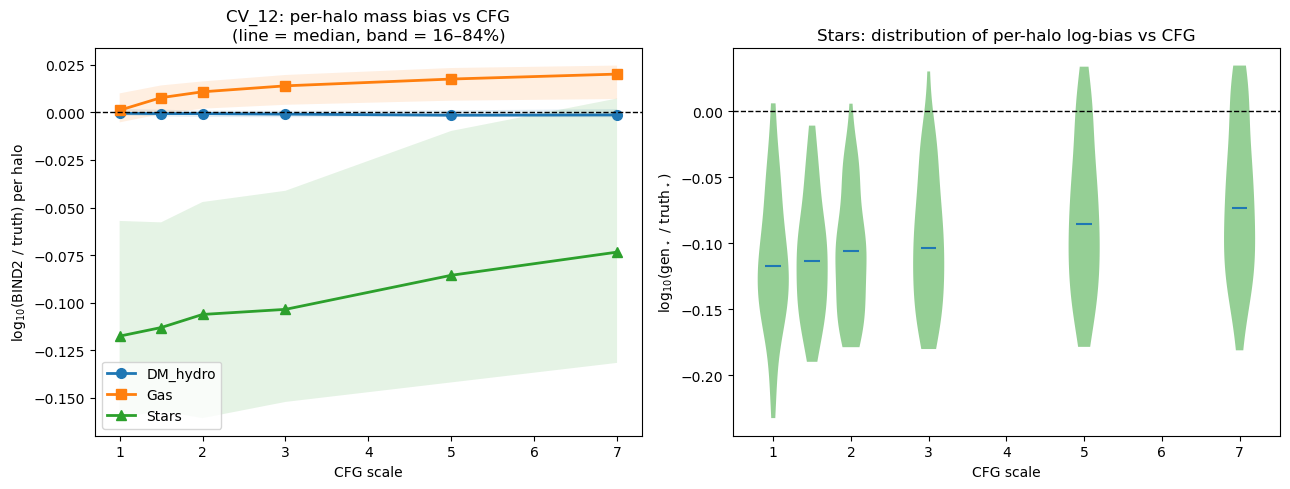

In [11]:
# Plot: median bias (dex) vs cfg, one line per channel + 16-84 band
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, marker in zip(CHANNEL_NAMES, ['o', 's', '^']):
    sub = summary[summary['channel'] == name]
    ax.plot(sub['cfg'], sub['med_dex'], marker=marker, lw=2, ms=7, label=name)
    ax.fill_between(sub['cfg'], sub['p16_dex'], sub['p84_dex'], alpha=0.12)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('CFG scale')
ax.set_ylabel(r'log$_{10}$(BIND2 / truth) per halo')
ax.set_title(f'CV_{SIM_ID}: per-halo mass bias vs CFG\n(line = median, band = 16–84%)')
ax.legend()

ax = axes[1]
# Stars-only: show full distribution per CFG as a violin
stars_data = [per_halo_log_ratio(gen_by_cfg[w], truth_patches, 2) for w in CFG_SCALES]
parts = ax.violinplot(stars_data, positions=CFG_SCALES, widths=0.4,
                      showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('C2'); pc.set_alpha(0.5)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('CFG scale')
ax.set_ylabel(r'log$_{10}$(gen$_\star$ / truth$_\star$)')
ax.set_title('Stars: distribution of per-halo log-bias vs CFG')

plt.tight_layout()
plt.show()

## Stars radial profile vs CFG

Confirms whether CFG just rescales the profile uniformly or also fixes the BCG vs satellite balance.

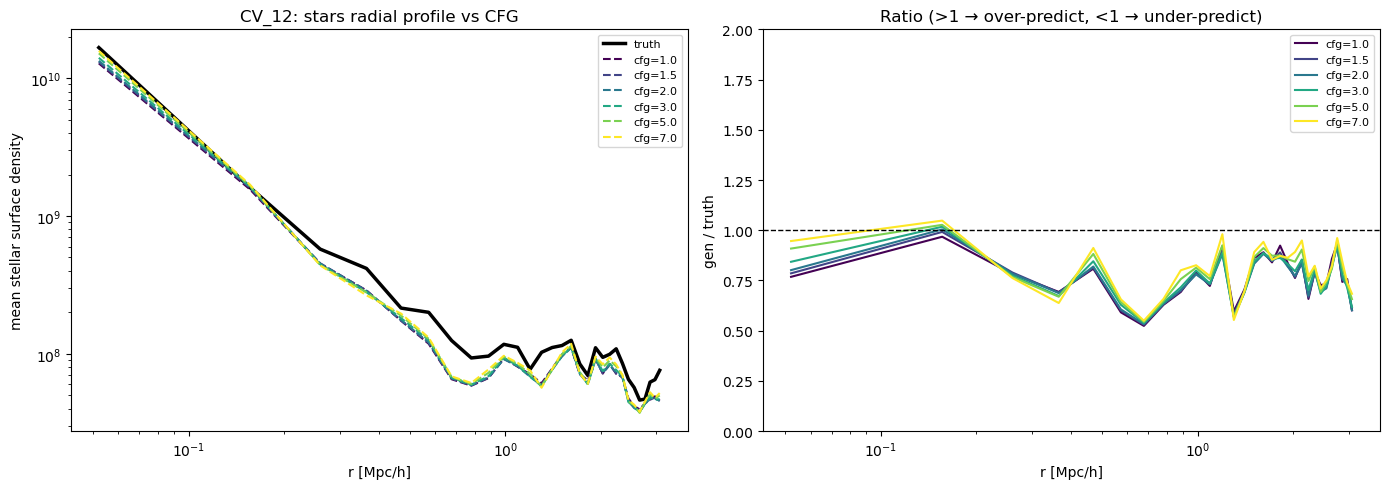

In [12]:
def radial_profile(patches, ch=2, n_bins=30):
    H = patches.shape[-1]
    cy, cx = H // 2, H // 2
    yy, xx = np.mgrid[:H, :H]
    r_pix = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    r_max = H // 2
    edges = np.linspace(0, r_max, n_bins + 1)
    mids  = 0.5 * (edges[:-1] + edges[1:]) * MPC_PER_PIX
    means = np.zeros(n_bins)
    for k in range(n_bins):
        m = (r_pix >= edges[k]) & (r_pix < edges[k+1])
        if m.sum() > 0:
            means[k] = patches[:, ch][:, m].mean()
    return mids, means

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={'height_ratios': [1]})
ax_p, ax_r = axes

r_t, p_t = radial_profile(truth_patches, ch=2)
ax_p.loglog(r_t, p_t, color='k', lw=2.5, label='truth')

cmap = plt.get_cmap('viridis')
for i, w in enumerate(CFG_SCALES):
    r_g, p_g = radial_profile(gen_by_cfg[w], ch=2)
    c = cmap(i / max(1, len(CFG_SCALES) - 1))
    ax_p.loglog(r_g, p_g, color=c, lw=1.5, ls='--', label=f'cfg={w}')
    ax_r.semilogx(r_g, p_g / np.where(p_t > 0, p_t, np.nan),
                  color=c, lw=1.5, label=f'cfg={w}')

ax_p.set_xlabel('r [Mpc/h]'); ax_p.set_ylabel('mean stellar surface density')
ax_p.set_title(f'CV_{SIM_ID}: stars radial profile vs CFG')
ax_p.legend(fontsize=8)

ax_r.axhline(1.0, color='k', ls='--', lw=1)
ax_r.set_xlabel('r [Mpc/h]'); ax_r.set_ylabel('gen / truth')
ax_r.set_title('Ratio (>1 → over-predict, <1 → under-predict)')
ax_r.set_ylim(0, 2)
ax_r.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Sanity check: DM and Gas should stay flat

If CFG breaks the well-calibrated channels, we want to see it here before tuning further.

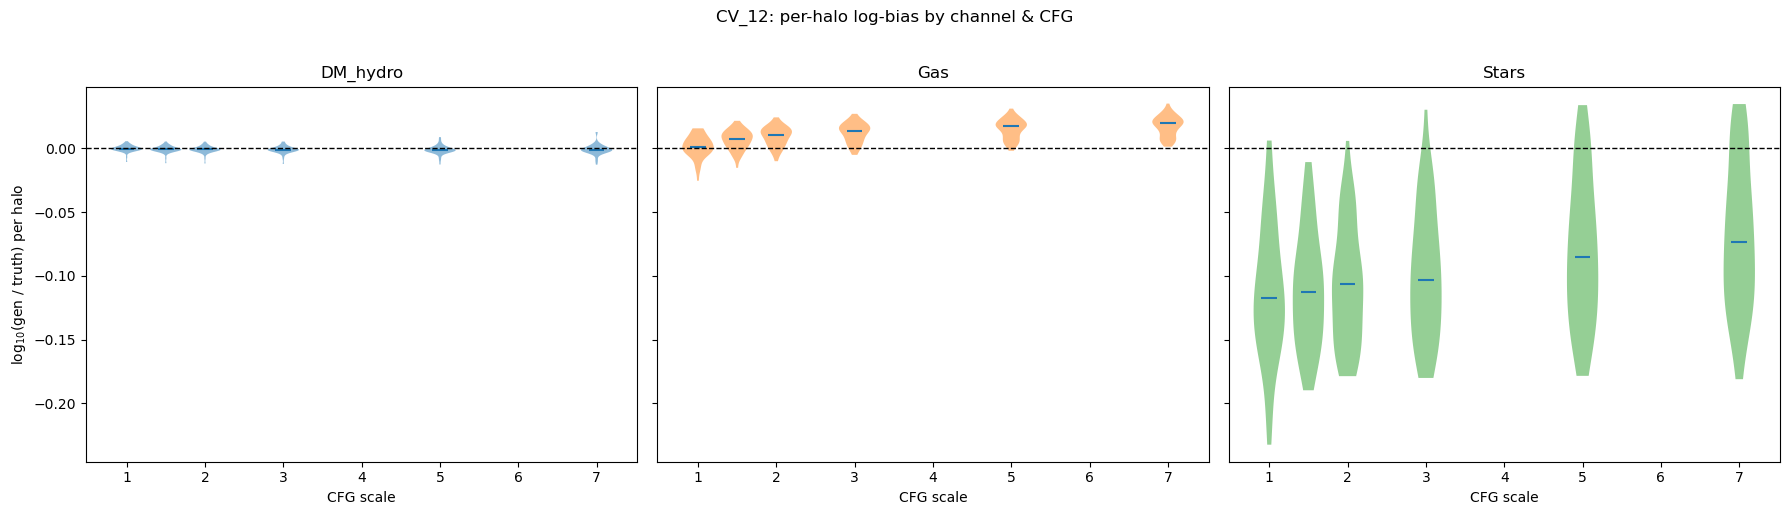

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, ch in zip(axes, range(3)):
    data = [per_halo_log_ratio(gen_by_cfg[w], truth_patches, ch) for w in CFG_SCALES]
    parts = ax.violinplot(data, positions=CFG_SCALES, widths=0.4,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(f'C{ch}'); pc.set_alpha(0.5)
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('CFG scale')
    ax.set_title(CHANNEL_NAMES[ch])
axes[0].set_ylabel(r'log$_{10}$(gen / truth) per halo')
plt.suptitle(f'CV_{SIM_ID}: per-halo log-bias by channel & CFG', y=1.02)
plt.tight_layout()
plt.show()